# Telco Customer Churn — Exploratory Data Analysis

**Case study: Identifying drivers of churn and high-risk segments**

---

## 1. Executive Summary

- **Overall churn rate:** ~26.5% (1,869 of 7,043 customers).
- **Strongest driver:** Month-to-month contract — churn is significantly lower for One-year and Two-year contracts.
- **High-risk profile:** Fiber + Month-to-month customers with monthly charges above $70 show the highest churn concentration. Tenure data reveals this risk peaks in the first 6–12 months — making early onboarding the critical intervention window.
- **Key segment:** Fiber + Month-to-month customers without Tech Support show very high churn; having Tech Support appears to have a protective effect even after controlling for contract type and price.
- **Top recommendation:** Run a controlled experiment offering free Tech Support for the first 3 months to Fiber + Month-to-month customers, and track 6-month churn.

## 2. Business Context & Problem Statement

A telecom company wants to understand **why customers are leaving** and **who is most at risk**, so the team can focus retention efforts where they'll actually make a difference.

**The problem:** Churn is expensive to recover from. Before touching pricing or product (like Tech Support), it's worth building a clear data-driven picture of the main drivers and the highest-risk customer profiles.

## 3. Dataset Overview

Starting with the basics — dataset shape, column types, missing values — and establishing the baseline churn rate before going any further.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use same data path as draft (adjust if your file is elsewhere)
DATA_PATH = Path("./data/Telco_customer_churn.xlsx")
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print(df.info())
print(df.describe(include="all").to_string())

Shape: (7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Intern

In [2]:
# Target: Churn Label (Yes = churned, No = retained)
TARGET = "Churn Label"
assert TARGET in df.columns
churn_counts = df[TARGET].value_counts()
n_yes = churn_counts.get("Yes", 0)
n_no = churn_counts.get("No", 0)
n_total = len(df)
baseline_churn_rate = n_yes / n_total * 100

print(f"Target: '{TARGET}' (Yes/No)")
print(f"Churned (Yes): {n_yes:,}  |  Retained (No): {n_no:,}  |  Total: {n_total:,}")
print(f"Baseline churn rate: {baseline_churn_rate:.2f}%")

Target: 'Churn Label' (Yes/No)
Churned (Yes): 1,869  |  Retained (No): 5,174  |  Total: 7,043
Baseline churn rate: 26.54%


## 4. Data Cleaning & Feature Preparation

A few things to sort out before the analysis:

- **Senior Citizen:** Stored as object (Yes/No) — treating it as a category, no conversion needed.
- **Total Charges:** Also object type; converting to numeric where needed, but the main analysis uses Monthly Charges.
- **Tenure bins:** 0–12, 13–24, 25–36, 37–48, 49–60, 61–72 months.
- **Monthly charge bins:** $0–20, $21–40, $41–60, $61–80, $81–100, $101–120.

In [3]:
# Tenure bins (months)
df["Tenure_Bins"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"],
)

# Monthly charge bins ($)
df["Monthly_Charges_Bins"] = pd.cut(
    df["Monthly Charges"],
    bins=[0, 20, 40, 60, 80, 100, 120],
    labels=["$0-20", "$21-40", "$41-60", "$61-80", "$81-100", "$101-120"],
)

# Senior Citizen as category (already Yes/No in draft)
df["Senior Citizen"] = df["Senior Citizen"].astype("category")

print("Derived features created: Tenure_Bins, Monthly_Charges_Bins")
print("Tenure_Bins value counts:")
print(df["Tenure_Bins"].value_counts().sort_index())

Derived features created: Tenure_Bins, Monthly_Charges_Bins
Tenure_Bins value counts:
Tenure_Bins
0-12     2175
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64


## 5. EDA

Before the charts, a quick helper to calculate churn rates by group alongside sample sizes — useful for spotting small segments where the rate might not be reliable.

In [4]:
def churn_rate_table(data, group_col, target="Churn Label", observed=True):
    """Group by group_col and return total count, churn count, churn rate (%)."""
    g = data.groupby(group_col, observed=observed)[target]
    total = g.count()
    churn_count = g.apply(lambda x: (x == "Yes").sum())
    rate = churn_count / total * 100
    return pd.DataFrame({"Total": total, "Churn_Count": churn_count, "Churn_Rate_%": rate})

### 5.1 Baseline churn and class balance

Just the overall split: roughly 1 in 4 customers churns. It's a meaningful rate and worth keeping in mind for any future modeling (class imbalance isn't extreme, but it's there).

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Proportions:
Churn Label
No     0.735
Yes    0.265
Name: proportion, dtype: float64


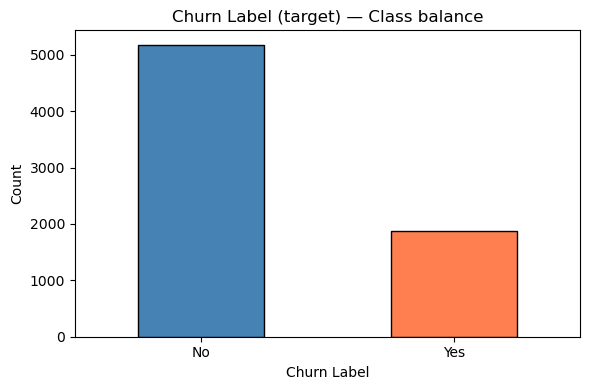

In [5]:
# Baseline and balance
print(df[TARGET].value_counts())
print("\nProportions:")
print(df[TARGET].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
df[TARGET].value_counts().plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
plt.title("Churn Label (target) — Class balance")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Churn Distribution Across the Customer Lifecycle

This chart shows **when** churn tends to happen, not **why**. Churn concentrates in the 0–12 month window and drops as tenure grows — but this is a lifecycle pattern, not a causal one. Customers who churned early have short tenure by definition; those who stayed 60+ months are, by survival, the most loyal. Interpreting tenure as a driver would introduce circular reasoning.

What the data does tell us: **the onboarding window is where the real drivers (contract type, price, service quality) exert the most pressure**. The following sections identify those levers.

             Total  Churn_Count  Churn_Rate_%
Tenure_Bins                                  
0-12          2175         1037         47.68
13-24         1024          294         28.71
25-36          832          180         21.63
37-48          762          145         19.03
49-60          832          120         14.42
61-72         1407           93          6.61


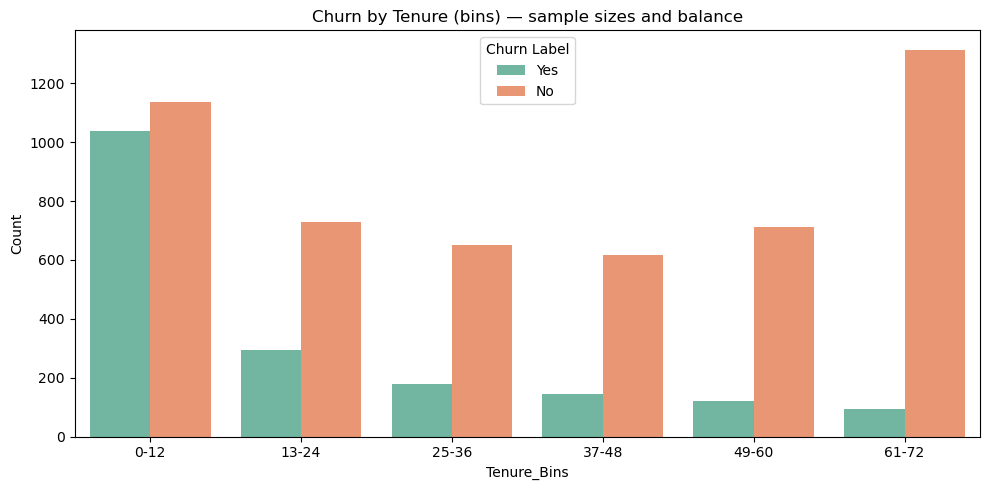

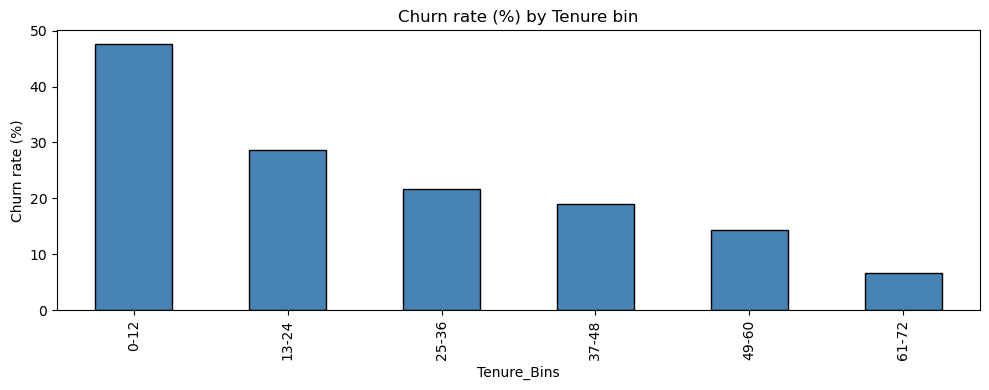

In [6]:
tb = churn_rate_table(df, "Tenure_Bins")
print(tb.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="Tenure_Bins", hue=TARGET, palette="Set2", ax=ax)
ax.set_title("Churn by Tenure (bins) — sample sizes and balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Trend: churn rate by tenure bin
ax2 = tb["Churn_Rate_%"].plot(kind="bar", figsize=(10, 4), color="steelblue", edgecolor="black")
ax2.set_title("Churn rate (%) by Tenure bin")
ax2.set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

### 5.3 Churn vs Contract type

Month-to-month customers churn at a much higher rate than those on one- or two-year contracts — and the gap is quite large. Contract type is the strongest single driver in this dataset, and converting M2M customers to annual plans is probably the most direct lever available for reducing churn.

                Total  Churn_Count  Churn_Rate_%
Contract                                        
Month-to-month   3875         1655         42.71
One year         1473          166         11.27
Two year         1695           48          2.83


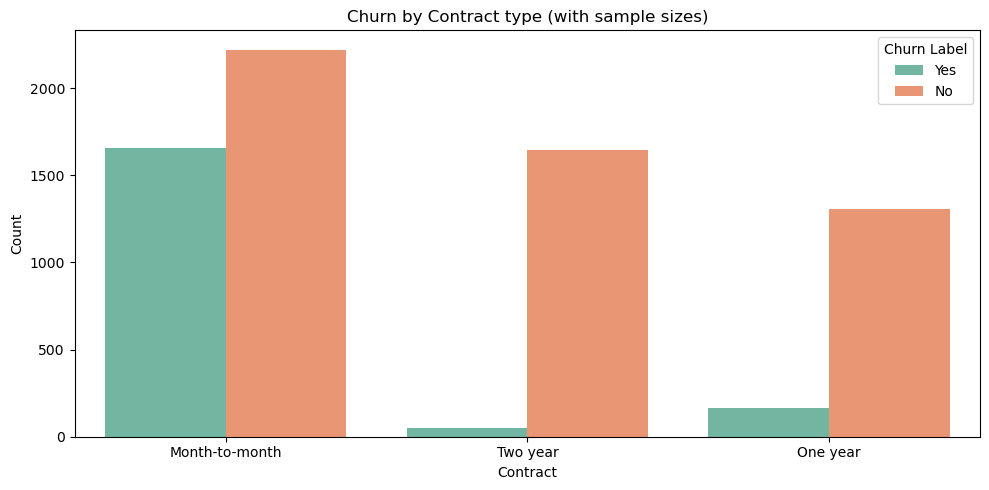

In [7]:
contract_tbl = churn_rate_table(df, "Contract")
print(contract_tbl.round(2))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Contract", hue=TARGET, palette="Set2")
plt.title("Churn by Contract type (with sample sizes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 5.4 Churn vs Monthly Charges

Higher monthly charges are associated with higher churn. On its own this could mean different things (more services = higher bill), but combined with M2M contracts it becomes more concerning — high bill + no long-term commitment is a risky combination that shows up clearly in the segment analysis.

                      Total  Churn_Count  Churn_Rate_%
Monthly_Charges_Bins                                  
$0-20                   656           58          8.84
$21-40                 1182          156         13.20
$41-60                 1080          276         25.56
$61-80                 1459          473         32.42
$81-100                1764          653         37.02
$101-120                902          253         28.05


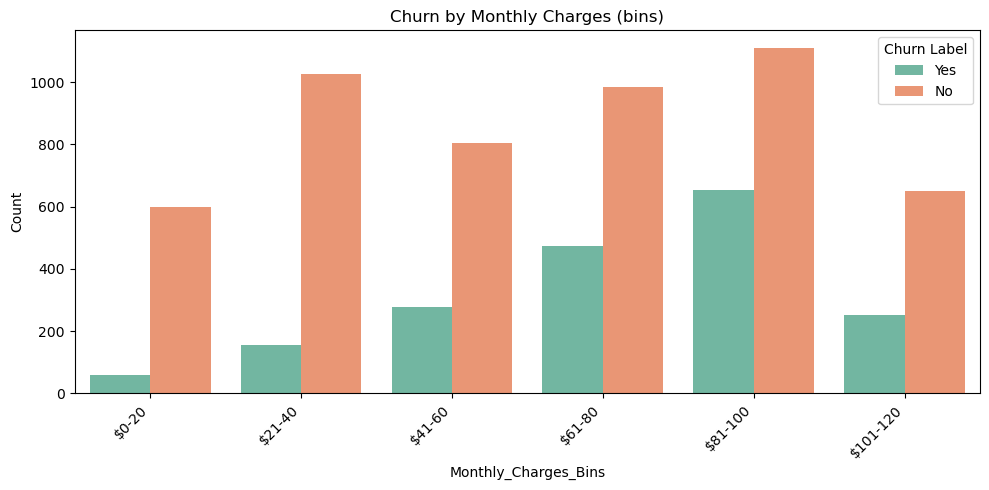

In [8]:
charge_tbl = churn_rate_table(df, "Monthly_Charges_Bins")
print(charge_tbl.round(2))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Monthly_Charges_Bins", hue=TARGET, palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Churn by Monthly Charges (bins)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 5.5 Interaction: Contract × Lifecycle Timing, Price × Contract

Looking at variables together rather than one at a time: M2M dominates risk at every price level and at every point in the lifecycle. The heatmap adds a timing insight — **for M2M customers, churn pressure is highest in the first 12 months**, which means the onboarding window is also the best moment to push a contract upgrade. Higher charges amplify this risk.

The key takeaway: Contract type and Monthly Charges are the drivers. The lifecycle view (tenure) tells us *when* to act, not *why* customers leave.

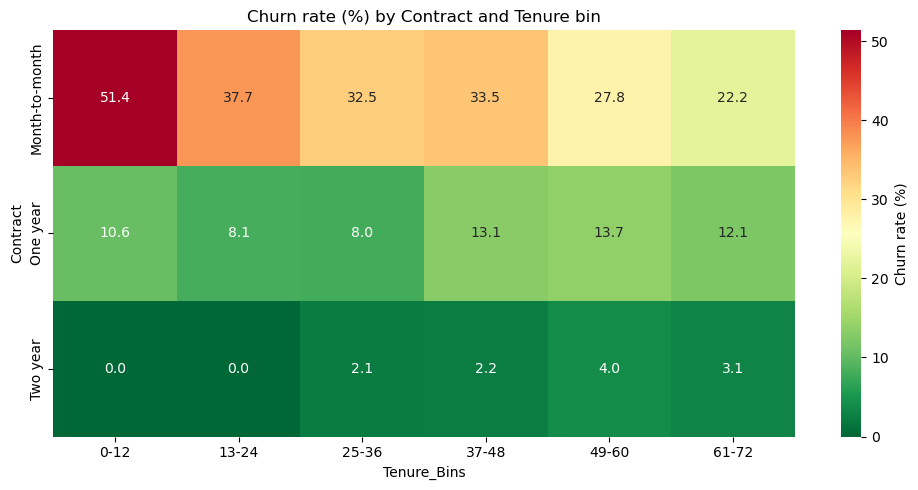

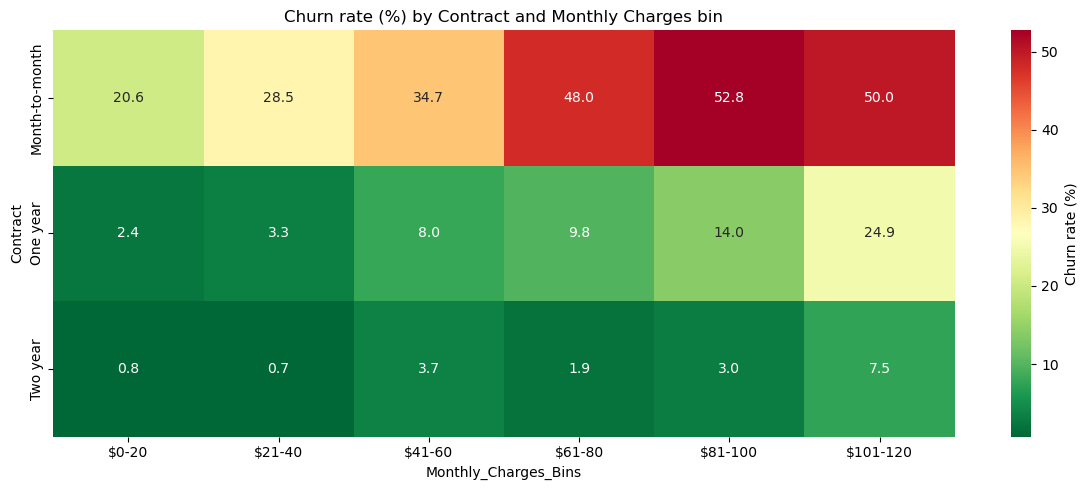

In [9]:
# Tenure x Contract — churn rate heatmap
rate_tenure_contract = df.groupby(["Contract", "Tenure_Bins"], observed=True)[TARGET].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(rate_tenure_contract, annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "Churn rate (%)"})
plt.title("Churn rate (%) by Contract and Tenure bin")
plt.tight_layout()
plt.show()

# Price x Contract (monthly charge bins)
rate_charge_contract = df.groupby(["Contract", "Monthly_Charges_Bins"], observed=True)[TARGET].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).unstack(fill_value=0)
plt.figure(figsize=(12, 5))
sns.heatmap(rate_charge_contract, annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "Churn rate (%)"})
plt.title("Churn rate (%) by Contract and Monthly Charges bin")
plt.tight_layout()
plt.show()

### 5.6 Tech Support analysis

Does having Tech Support make a difference? First the overall picture (Yes / No / No internet service), then zooming in on **Fiber + Month-to-month** customers — the highest-risk group — to check if the pattern holds when the context is narrowed. Also broken down by price bin within that group.

The data shows a pattern consistent with a **protective effect** of Tech Support within this segment, but this is observational. Customers who opt in to Tech Support may differ in other ways, so this can't be interpreted as causal (see Section 8 for limitations). The experiment in Section 7 is there to actually test it.

Churn by Tech Support:
                     Total  Churn_Count  Churn_Rate_%
Tech Support                                         
No                    3473         1446         41.64
No internet service   1526          113          7.40
Yes                   2044          310         15.17


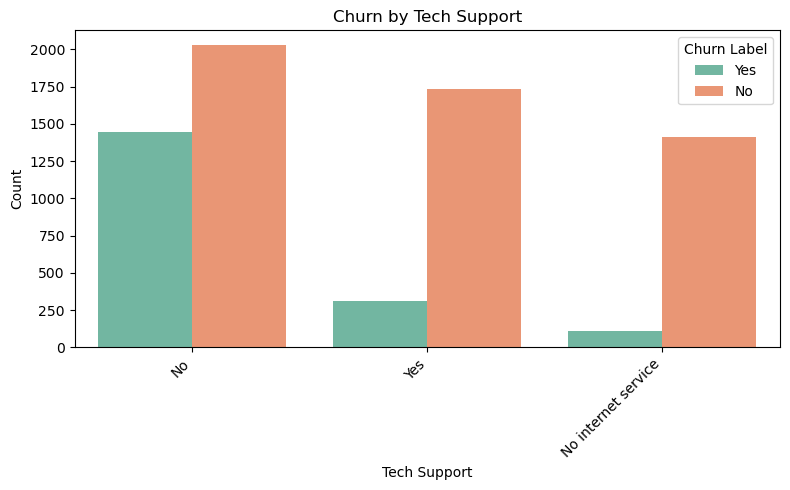

In [10]:
# Churn by Tech Support (all customers)
tech_tbl = churn_rate_table(df, "Tech Support")
print("Churn by Tech Support:")
print(tech_tbl.round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Tech Support", hue=TARGET, palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Churn by Tech Support")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Fiber + Month-to-month only:
              Without Tech Support  With Tech Support
Total                      1796.00             332.00
Churn_Count                1033.00             129.00
Churn_Rate_%                 57.52              38.86

Difference (Without − With): 18.66 pp — evidence consistent with Tech Support reducing churn in this segment.


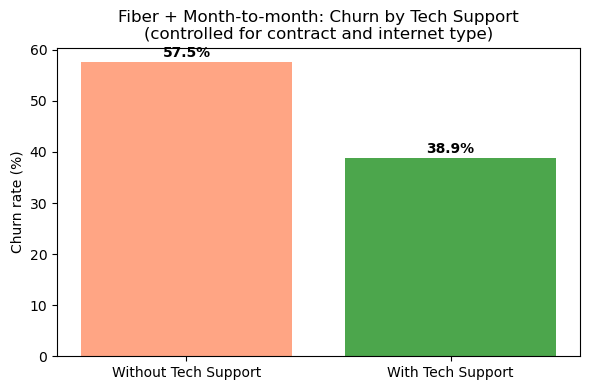

In [11]:
# Conditional: Fiber + Month-to-month only — with vs without Tech Support
fiber_m2m = df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "Month-to-month")]

seg_sin_tech = fiber_m2m[fiber_m2m["Tech Support"] == "No"]
seg_con_tech = fiber_m2m[fiber_m2m["Tech Support"] == "Yes"]

n_sin = len(seg_sin_tech)
n_con = len(seg_con_tech)
rate_sin = (seg_sin_tech[TARGET] == "Yes").sum() / n_sin * 100 if n_sin else 0
rate_con = (seg_con_tech[TARGET] == "Yes").sum() / n_con * 100 if n_con else 0
diff_pp = rate_sin - rate_con

print("Fiber + Month-to-month only:")
print(pd.DataFrame({
    "Without Tech Support": [n_sin, (seg_sin_tech[TARGET] == "Yes").sum(), rate_sin],
    "With Tech Support": [n_con, (seg_con_tech[TARGET] == "Yes").sum(), rate_con],
}, index=["Total", "Churn_Count", "Churn_Rate_%"]).round(2))
print(f"\nDifference (Without − With): {diff_pp:.2f} pp — evidence consistent with Tech Support reducing churn in this segment.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Without Tech Support", "With Tech Support"], [rate_sin, rate_con], color=["coral", "green"], alpha=0.7)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Fiber + Month-to-month: Churn by Tech Support\n(controlled for contract and internet type)")
for i, v in enumerate([rate_sin, rate_con]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Churn rate (%) by Monthly Charges bin and Tech Support (Fiber + Month-to-month):
Tech Support             No    Yes
Monthly_Charges_Bins              
$61-80                59.79  29.17
$81-100               55.94  41.36
$101-120              57.49  36.75


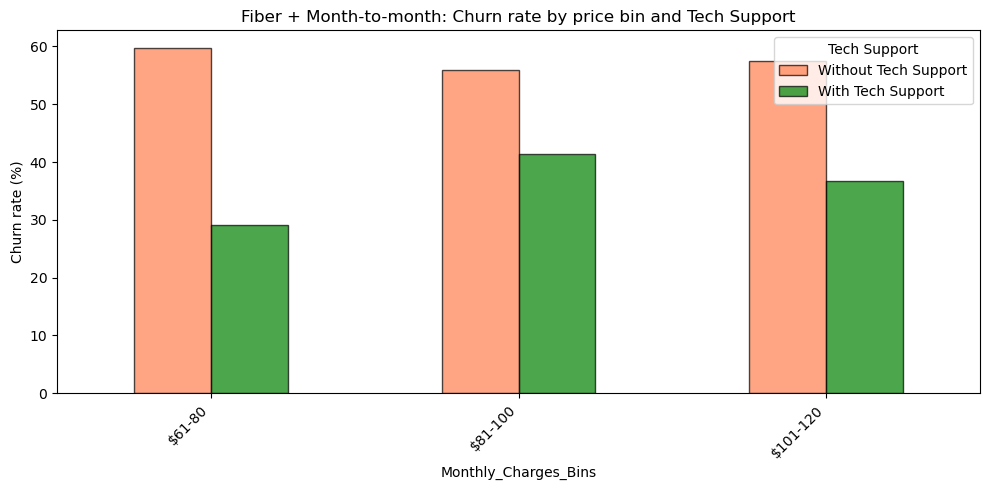

In [12]:
# Tech Support effect across price bins — Fiber + Month-to-month
tech_price = fiber_m2m.groupby(["Monthly_Charges_Bins", "Tech Support"], observed=True)[TARGET].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).unstack(fill_value=0)

print("Churn rate (%) by Monthly Charges bin and Tech Support (Fiber + Month-to-month):")
print(tech_price.round(2))

# Plot (only columns that exist)
plot_cols = [c for c in ["No", "Yes"] if c in tech_price.columns]
if plot_cols:
    tech_price_plot = tech_price[plot_cols].rename(columns={"No": "Without Tech Support", "Yes": "With Tech Support"})
    tech_price_plot.plot(kind="bar", figsize=(10, 5), color=["coral", "green"][: len(plot_cols)], alpha=0.7, edgecolor="black")
    plt.title("Fiber + Month-to-month: Churn rate by price bin and Tech Support")
    plt.ylabel("Churn rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Tech Support")
    plt.tight_layout()
    plt.show()

## 6. High-Risk Segment Definition & Impact

Based on the EDA, the high-risk segment is defined by three **actionable** conditions — variables the business can intervene on:

- **Contract** = Month-to-month  
- **Internet Service** = Fiber optic  
- **Monthly Charges** > $70  

Tenure is **not** used as a defining criterion. It's a consequence of churn timing, not a cause — and it isn't actionable at signup. Instead, tenure appears below as a descriptive lens: it shows *when* this segment's risk peaks, which informs the timing of retention interventions.

For this group: total size, churn rate, share of all churn, and a concentration ratio (share of churn / share of customers) to quantify how disproportionately churn loads into this segment.

In [13]:
# High-risk segment — defined by actionable variables only
segment = df[
    (df["Contract"] == "Month-to-month")
    & (df["Internet Service"] == "Fiber optic")
    & (df["Monthly Charges"] > 70)
]

n_seg = len(segment)
churn_seg = (segment[TARGET] == "Yes").sum()
rate_seg = churn_seg / n_seg * 100 if n_seg else 0

n_tot = len(df)
churn_tot = (df[TARGET] == "Yes").sum()
pct_churn_explained = churn_seg / churn_tot * 100 if churn_tot else 0
pct_customers = n_seg / n_tot * 100
concentration_ratio = pct_churn_explained / pct_customers if pct_customers else 0

print("High-risk segment: Contract = Month-to-month, Internet = Fiber optic, Monthly Charges > $70")
print(pd.Series({
    "Segment size": n_seg,
    "Segment churn count": churn_seg,
    "Segment churn rate (%)": round(rate_seg, 2),
    "Share of total churn (%)": round(pct_churn_explained, 2),
    "Share of customers (%)": round(pct_customers, 2),
    "Concentration ratio": round(concentration_ratio, 2),
}))

# Interpretation
if pct_churn_explained >= 40:
    print("\n→ Segment explains 40%+ of churn: strong strategic focus.")
elif pct_churn_explained >= 20:
    print("\n→ Segment explains 20–40% of churn: relevant but not the only lever.")
else:
    print("\n→ Segment explains <20% of churn: consider refining definition or other segments.")

# Lifecycle view: tenure as a descriptive lens on this segment (not a defining criterion)
pct_early = (segment["Tenure Months"] <= 12).mean() * 100
median_tenure = segment["Tenure Months"].median()
print(f"\nLifecycle view (tenure as descriptor, not driver):")
print(f"  {pct_early:.1f}% of this segment are in their first 12 months.")
print(f"  Median tenure in segment: {median_tenure:.0f} months.")
print(f"  → Onboarding interventions will reach the majority of at-risk customers.")

High-risk segment: Contract = Month-to-month, Internet = Fiber optic, Monthly Charges > $70
Segment size                2017.00
Segment churn count         1092.00
Segment churn rate (%)        54.14
Share of total churn (%)      58.43
Share of customers (%)        28.64
Concentration ratio            2.04
dtype: float64

→ Segment explains 40%+ of churn: strong strategic focus.

Lifecycle view (tenure as descriptor, not driver):
  41.2% of this segment are in their first 12 months.
  Median tenure in segment: 17 months.
  → Onboarding interventions will reach the majority of at-risk customers.


## 7. Recommendations

1. **Focus retention on the high-risk segment from day one** (Fiber + M2M + Monthly Charges > $70). This profile is identifiable at signup — no need to wait for churn signals. Tenure data shows the risk peaks in the first 6–12 months, so early onboarding check-ins are the right intervention mechanism.
2. **Push toward longer contracts for at-risk M2M customers.** The churn gap between M2M and one- or two-year plans is substantial; even modest conversion rates could move the needle.
3. **Offer Tech Support to high-risk Fiber + M2M customers** — the association in the data is suggestive, but validate with an experiment before scaling it up.
4. **Run an A/B test:** Offer free Tech Support for the first 3 months to a randomly selected group of new or at-risk **Fiber + Month-to-month** customers.
   - **Design:** Randomize eligible customers into Treatment (free Tech Support, first 3 months) vs Control (status quo). Track for 6 months.
   - **KPIs:** 6-month cumulative churn, retention curve, conversion to annual plan, cost per retained customer.
   - **Success:** A statistically significant reduction in 6-month churn in Treatment vs Control, at a cost-per-saved-customer that makes business sense.

## 8. Limitations

- **Observational data only.** All associations here (including Tech Support) are correlational. Customers who choose certain plans or add-ons are likely self-selected in ways we can't fully control for. No causal claims can be made without a controlled experiment.
- **Single geography.** The dataset covers California only — patterns may not generalize to other regions or markets.
- **Churn reasons are sparse.** The `Churn Reason` column is only populated for churned customers (~1,869 rows out of 7,043) and may reflect what customers said rather than the actual driver.
- **No time dimension.** This is a cross-sectional snapshot. We can't track how individual customer behavior changes over time or separate cohort effects from lifecycle effects.
- **Confounding in the Tech Support analysis.** Customers without internet service are excluded from the Tech Support comparison, but other confounders (usage patterns, plan tier, geography) are not controlled.
- **Tenure is not a causal variable.** The lifecycle charts (Section 5.2, 5.5) show *when* churn happens, not *why*. Customers who churned early have short tenure by definition — that's a consequence, not a cause. The high-risk segment (Section 6) is therefore defined exclusively by actionable variables (Contract, Internet Service, Monthly Charges). Tenure appears only as a descriptive lens to time interventions.

## 9. Appendix

Quick reference table: overall churn rate by Contract type.

In [14]:
# Appendix: Contract churn summary
print(contract_tbl.round(2))

                Total  Churn_Count  Churn_Rate_%
Contract                                        
Month-to-month   3875         1655         42.71
One year         1473          166         11.27
Two year         1695           48          2.83
